  pygam OK — version 0.12.0

DENGUE PREDICTION — KASKI DISTRICT (IMPROVED PIPELINE)

  Rows       : 84
  Period     : Jan 2019 – Dec 2025
  Outcome    : dengue_cases
  Predictors : ['EVI', 'LST_Night', 'Precip']

SECTION 2: DESCRIPTIVE STATISTICS

                  n     Mean    Min     5%     25%     50%      75%      95%       99%       Max
dengue_cases  84.0  164.607  0.000  0.000   0.000   2.000   37.500  955.900  2563.960  3799.000
EVI           84.0    0.267  0.185  0.199   0.222   0.263    0.314    0.360     0.381     0.395
LST_Night     84.0    4.318 -2.197 -0.606   2.066   4.159    6.937    8.651     9.870    10.552
Precip        84.0  178.130  2.959  4.519  13.179  77.186  338.936  532.637   592.517   650.532

  Saved: 01_descriptive_statistics.csv

SECTION 3: TIME SERIES PLOTS
    Saved: 02_timeseries_plot.png


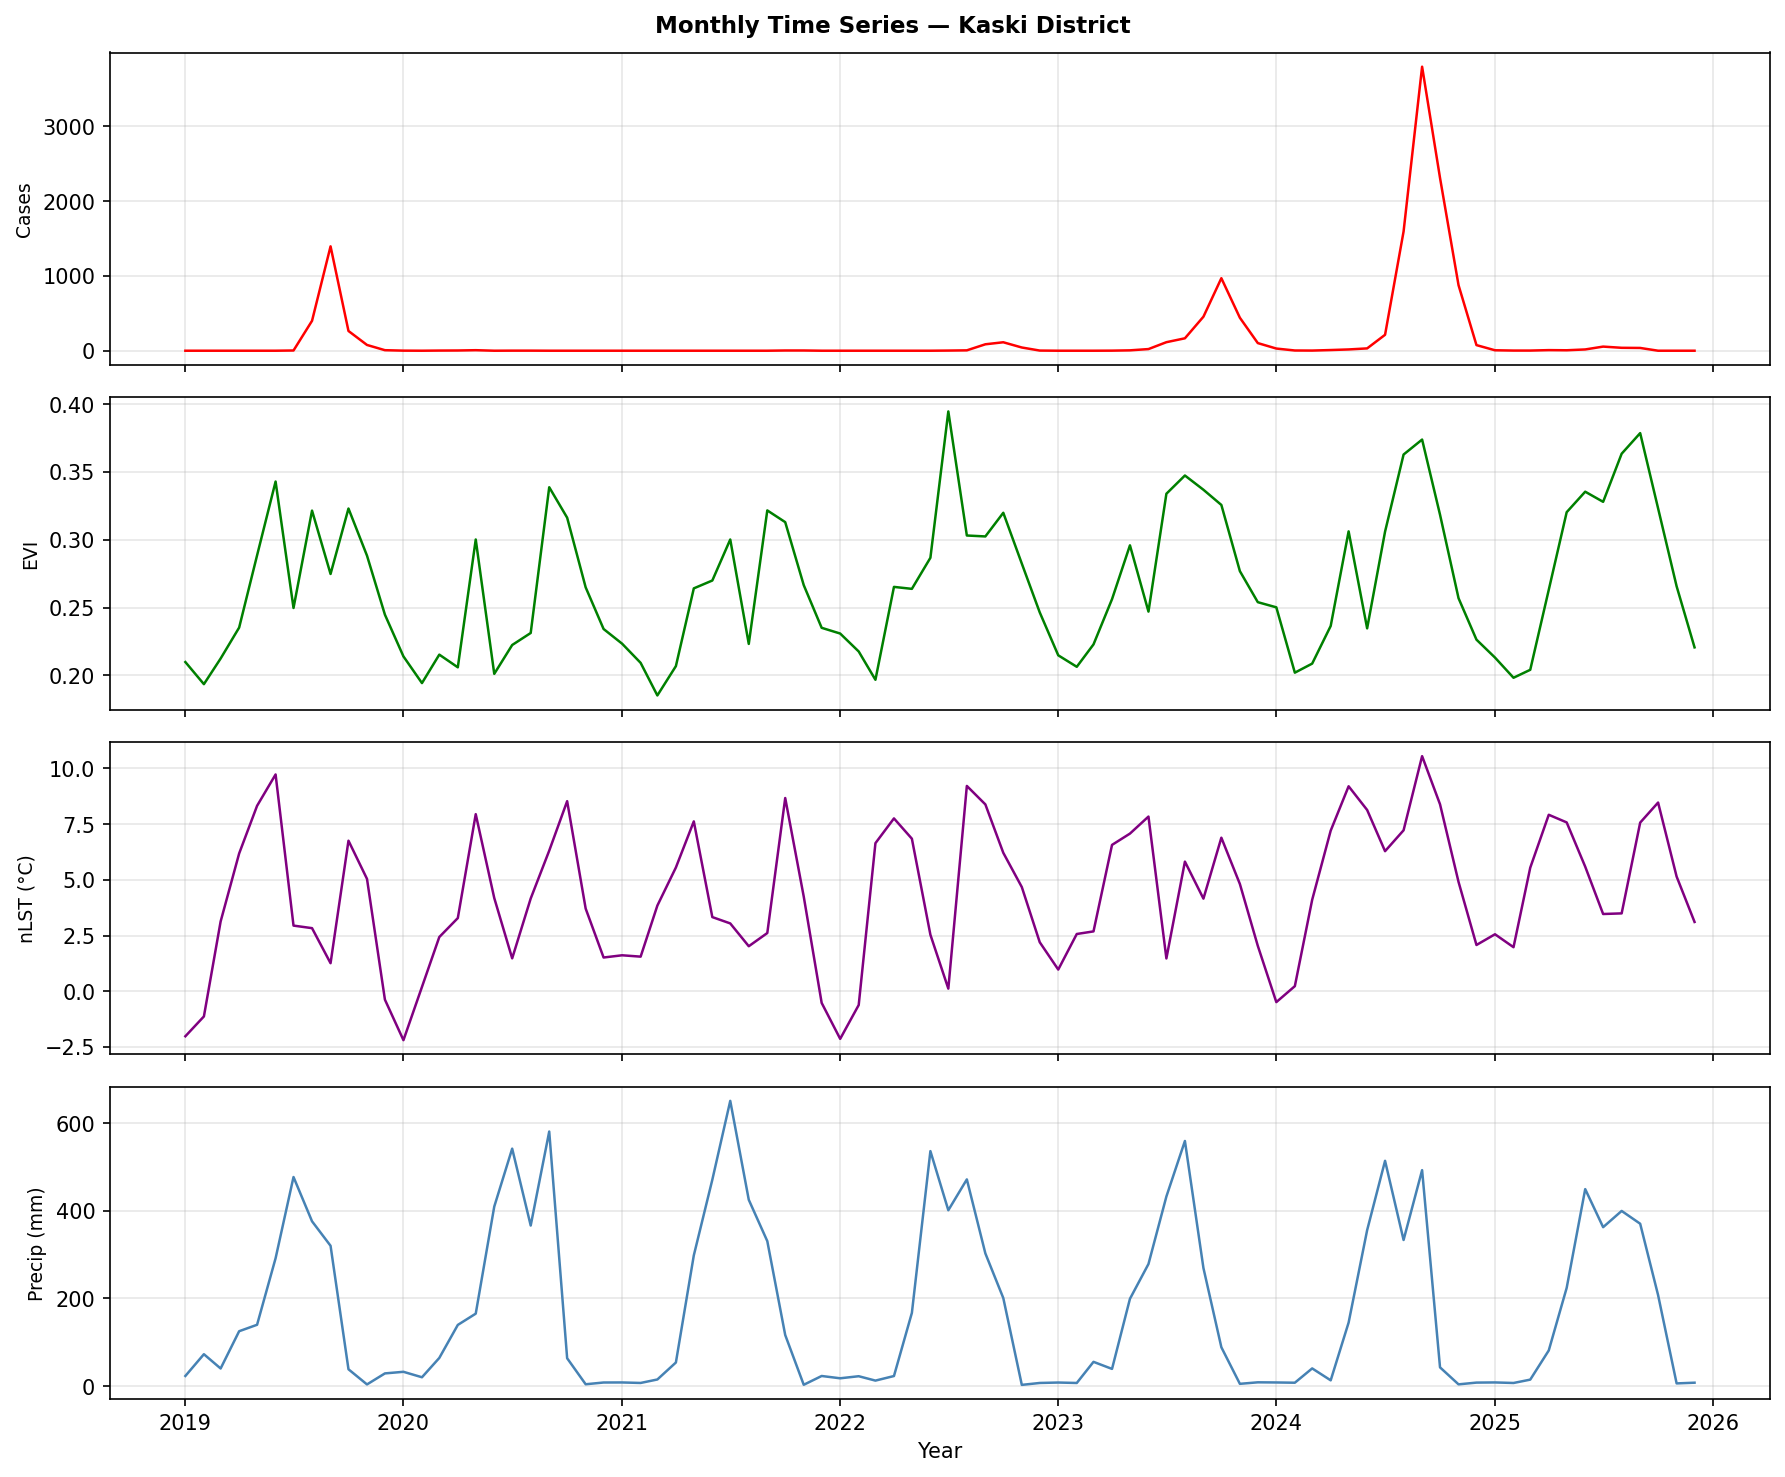


SECTION 4: INTER-PREDICTOR CORRELATION MATRIX

              EVI  LST_Night  Precip
EVI        1.000      0.493   0.547
LST_Night  0.493      1.000   0.222
Precip     0.547      0.222   1.000

Pairs |r| > 0.7 — excluded from same model:
  None above threshold — all variables eligible.
    Saved: 04_correlation_heatmap.png


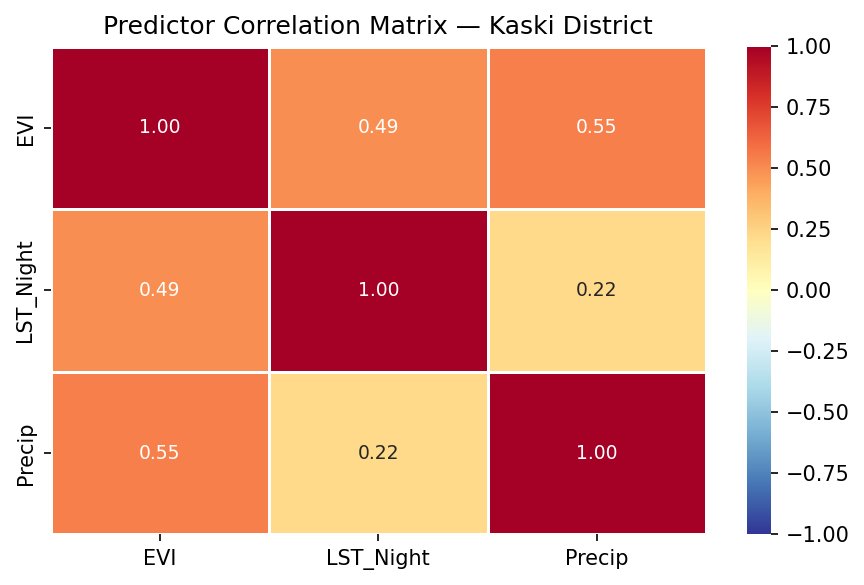


SECTION 5: CROSS-CORRELATION (Lags 0–6)

Variable      Lag        r          p    Sig
---------------------------------------------
  EVI           0    0.357     0.0008   Yes*
  EVI           1    0.394     0.0002   Yes*
  EVI           2    0.252     0.0223   Yes*
  EVI           3    0.146     0.1925     No
  EVI           4    0.058     0.6104     No
  EVI           5   -0.081     0.4776     No
  EVI           6   -0.220     0.0528     No

  LST_Night     0    0.267     0.0142   Yes*
  LST_Night     1    0.231     0.0359   Yes*
  LST_Night     2    0.204     0.0665     No
  LST_Night     3    0.287     0.0094   Yes*
  LST_Night     4    0.336     0.0023   Yes*
  LST_Night     5    0.247     0.0281   Yes*
  LST_Night     6    0.026     0.8233     No

  Precip        0    0.146     0.1850     No
  Precip        1    0.290     0.0079   Yes*
  Precip        2    0.382     0.0004   Yes*
  Precip        3    0.262     0.0182   Yes*
  Precip        4    0.059     0.6008     No
  Precip  

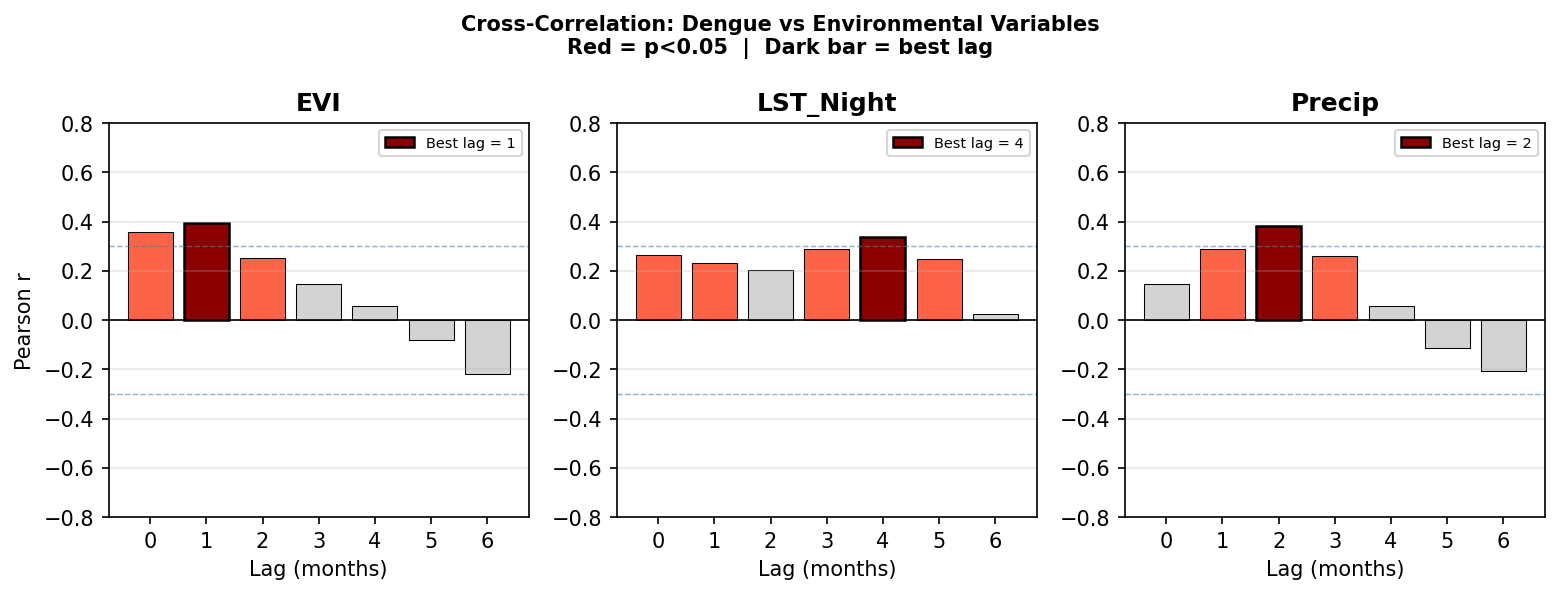


SECTION 6: FEATURE ENGINEERING
  EVI_lag1
  LST_Night_lag4
  Precip_lag2
  cases_lag1, cases_lag2  (AR raw scale for RF/SVM)
  log_cases_lag1, log_cases_lag2  (AR log scale for GAM)
  month_sin, month_cos  (cyclical seasonality)

  Observations retained: 80

  GAM features : ['log_cases_lag1', 'log_cases_lag2', 'EVI_lag1', 'LST_Night_lag4', 'Precip_lag2']
  ML features  : ['EVI_lag1', 'LST_Night_lag4', 'Precip_lag2', 'cases_lag1', 'cases_lag2', 'month_sin', 'month_cos']

  Feature correlations with log(cases):
    log_cases_lag1              : r=0.864  p=0.0000  ***
    log_cases_lag2              : r=0.607  p=0.0000  ***
    EVI_lag1                    : r=0.491  p=0.0000  ***
    LST_Night_lag4              : r=0.319  p=0.0039  **
    Precip_lag2                 : r=0.416  p=0.0001  ***

SECTION 7: OVERDISPERSION CHECK

  Deviance         : 21478.92
  df residual      : 76
  Dispersion ratio : 282.62
  >> Severe overdispersion detected.
  >> Using LinearGAM on log1p(cases).
  >> Pre

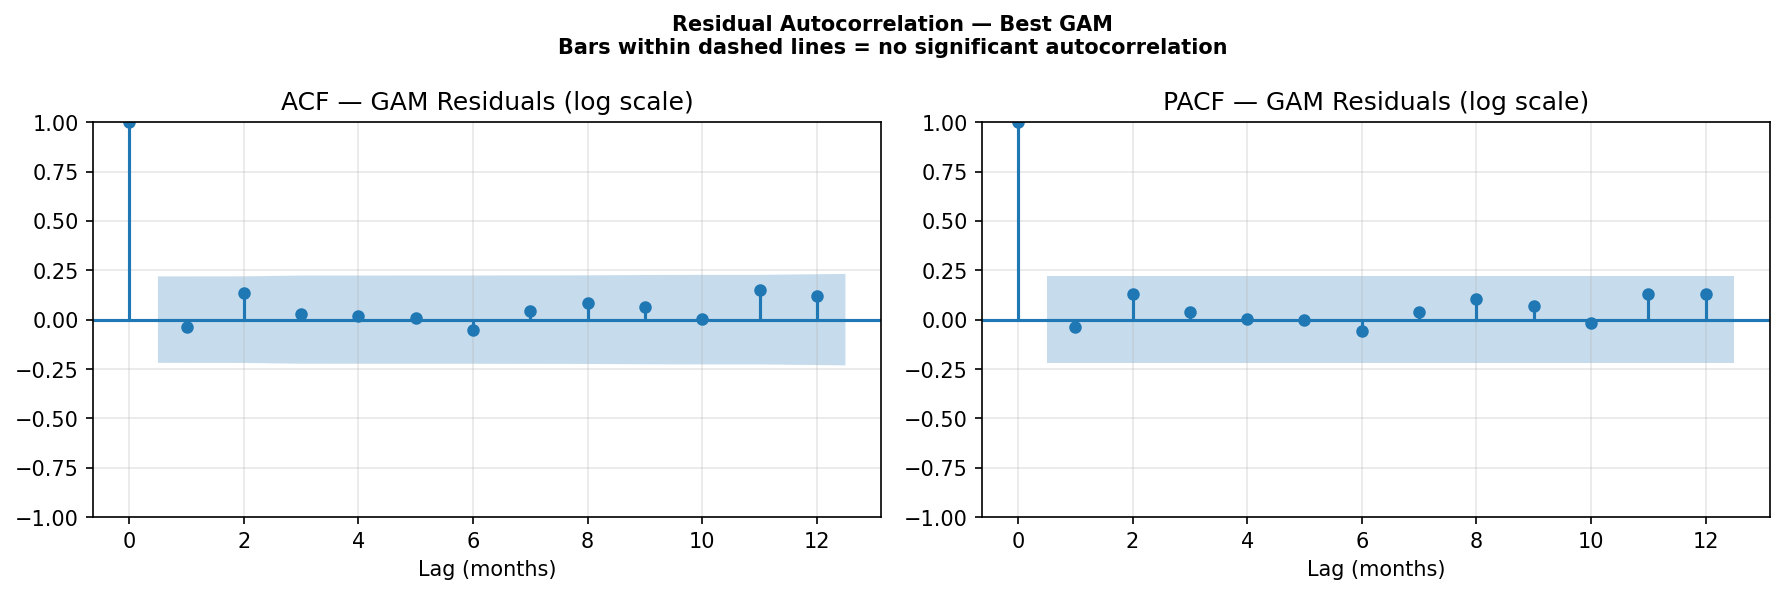

  Mean residual : 0.0000
  Std residual  : 0.9870

SECTION 12: 10-FOLD TIME-SERIES CV

  10-fold TimeSeriesSplit — no shuffle

  Fold   Train   Test    GAM RMSE    RF RMSE   SVM RMSE
  ----------------------------------------------------
     1      10      7      1050.7      371.5       96.6
     2      17      7         0.0      156.7       29.2
     3      24      7         1.5      132.3       10.8
     4      31      7         0.1       43.5        2.3
     5      38      7        45.7       90.2       51.0
     6      45      7        56.8       37.8       67.7
     7      52      7       320.6      222.4      384.9
     8      59      7       930.8     1367.3     1720.2
     9      66      7        70.1      453.7      301.6
    10      73      7        42.3      468.0       57.2

SECTION 13: MODEL PERFORMANCE — OUT-OF-SAMPLE CV

  Model                  RMSE      MAE       R2  Pearson_r
  --------------------------------------------------------
  GAM                 456.6    13

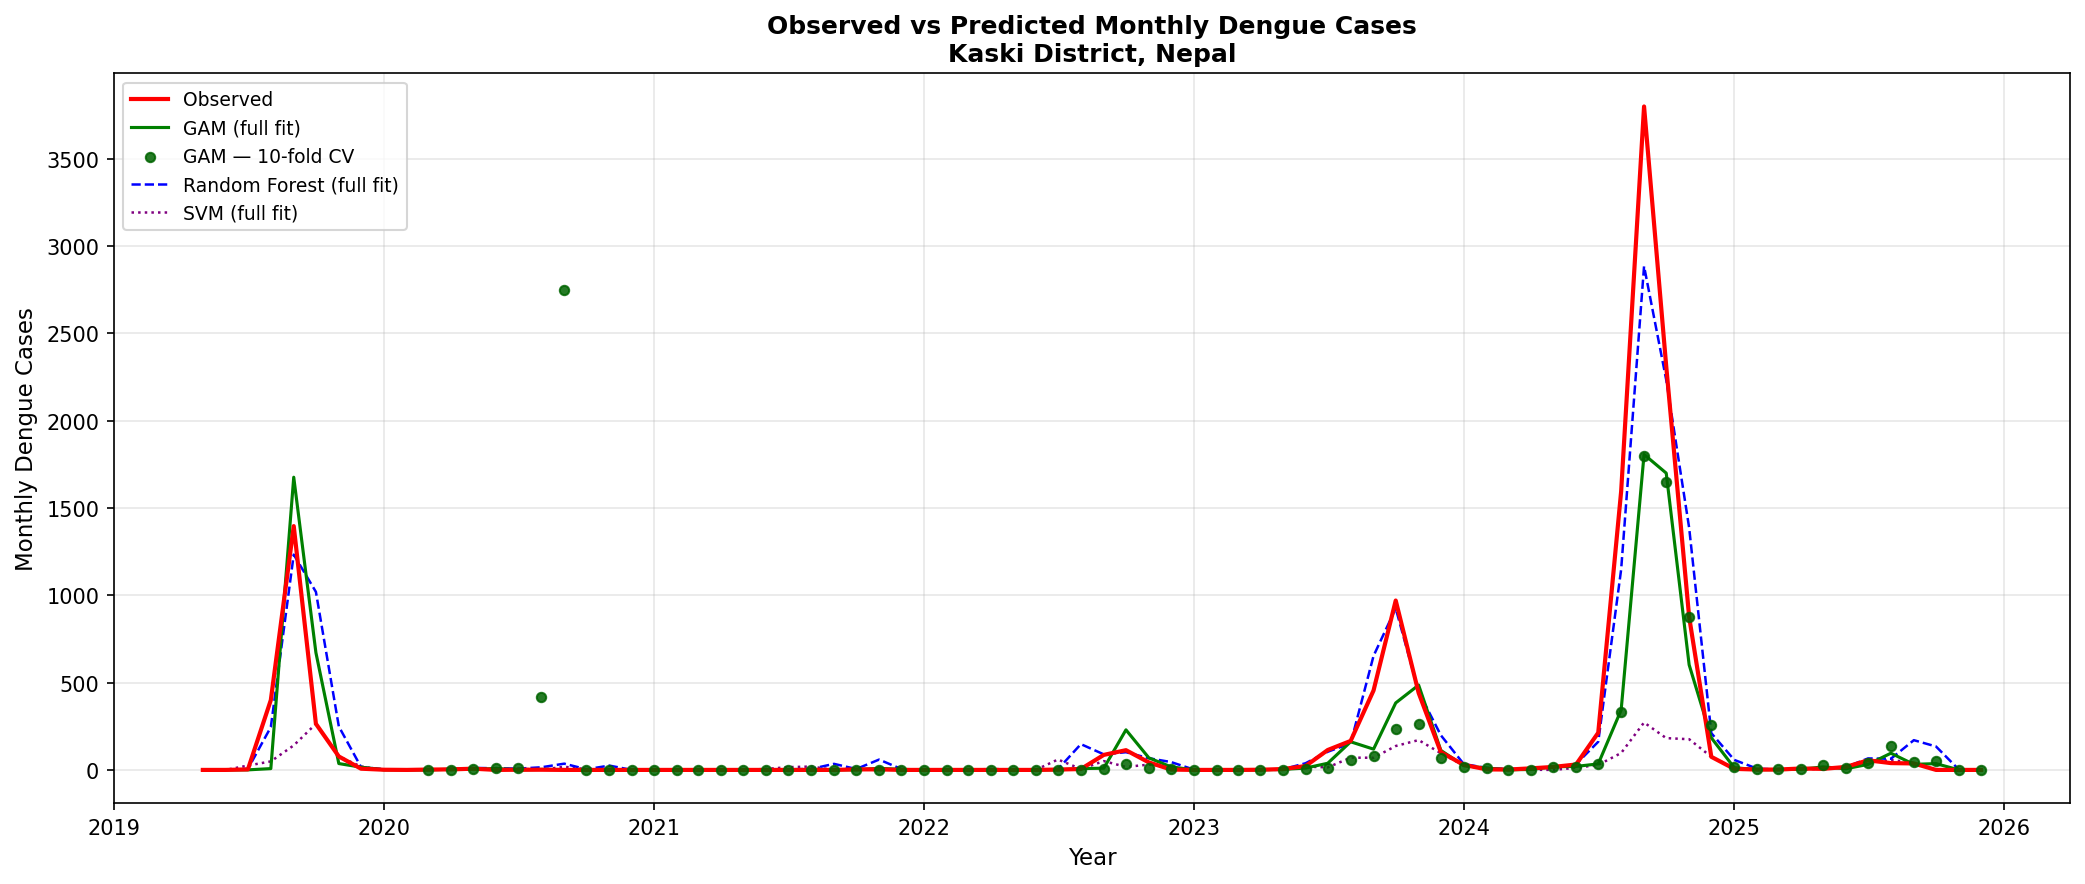


SECTION 16: SCATTER PLOTS
    Saved: 12_scatter_obs_pred.png


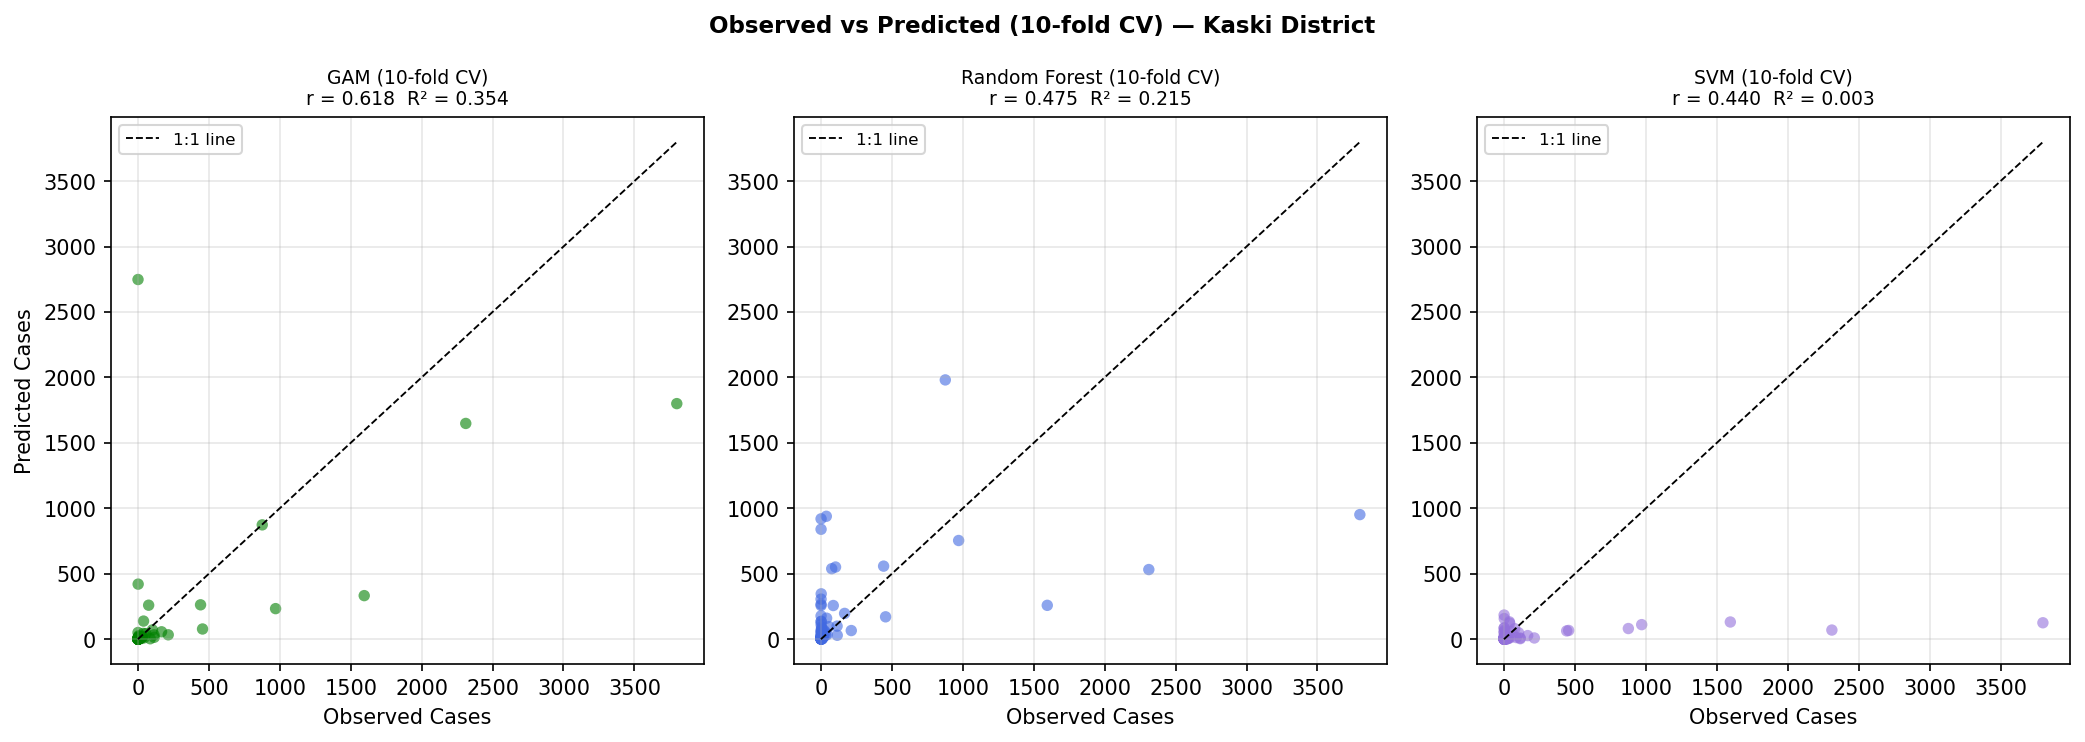


SECTION 17: RANDOM FOREST FEATURE IMPORTANCE
    Saved: 13_feature_importance.png


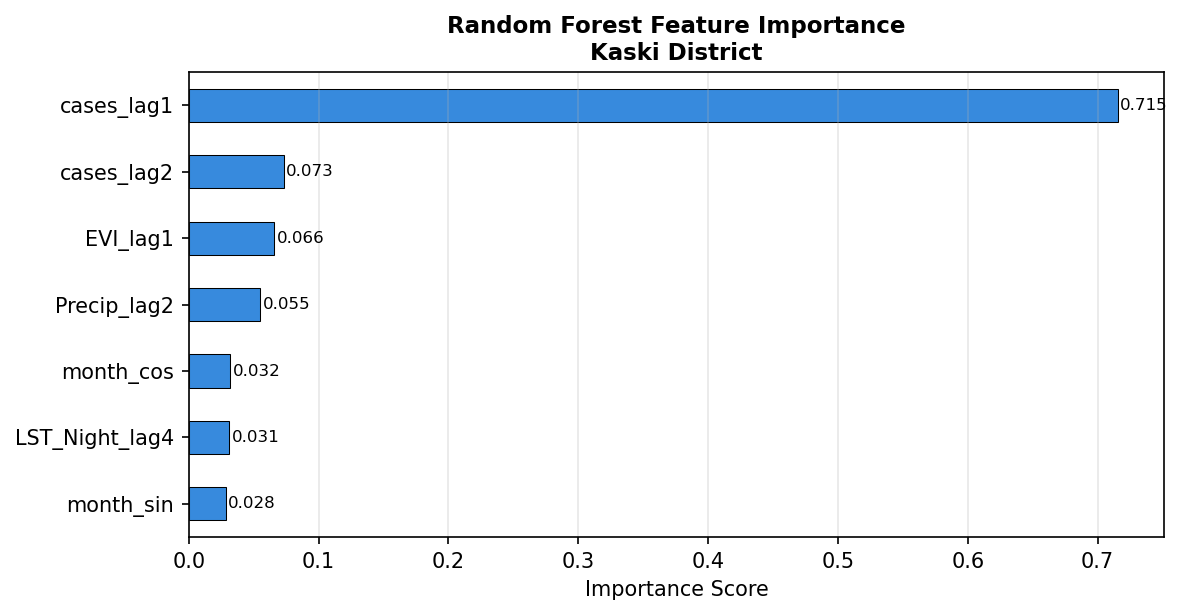


  Ranking:
    cases_lag1                      : 0.7154
    cases_lag2                      : 0.0729
    EVI_lag1                        : 0.0656
    Precip_lag2                     : 0.0549
    month_cos                       : 0.0317
    LST_Night_lag4                  : 0.0311
    month_sin                       : 0.0283

SECTION 18: MODEL COMPARISON CHART
    Saved: 14_model_comparison_chart.png


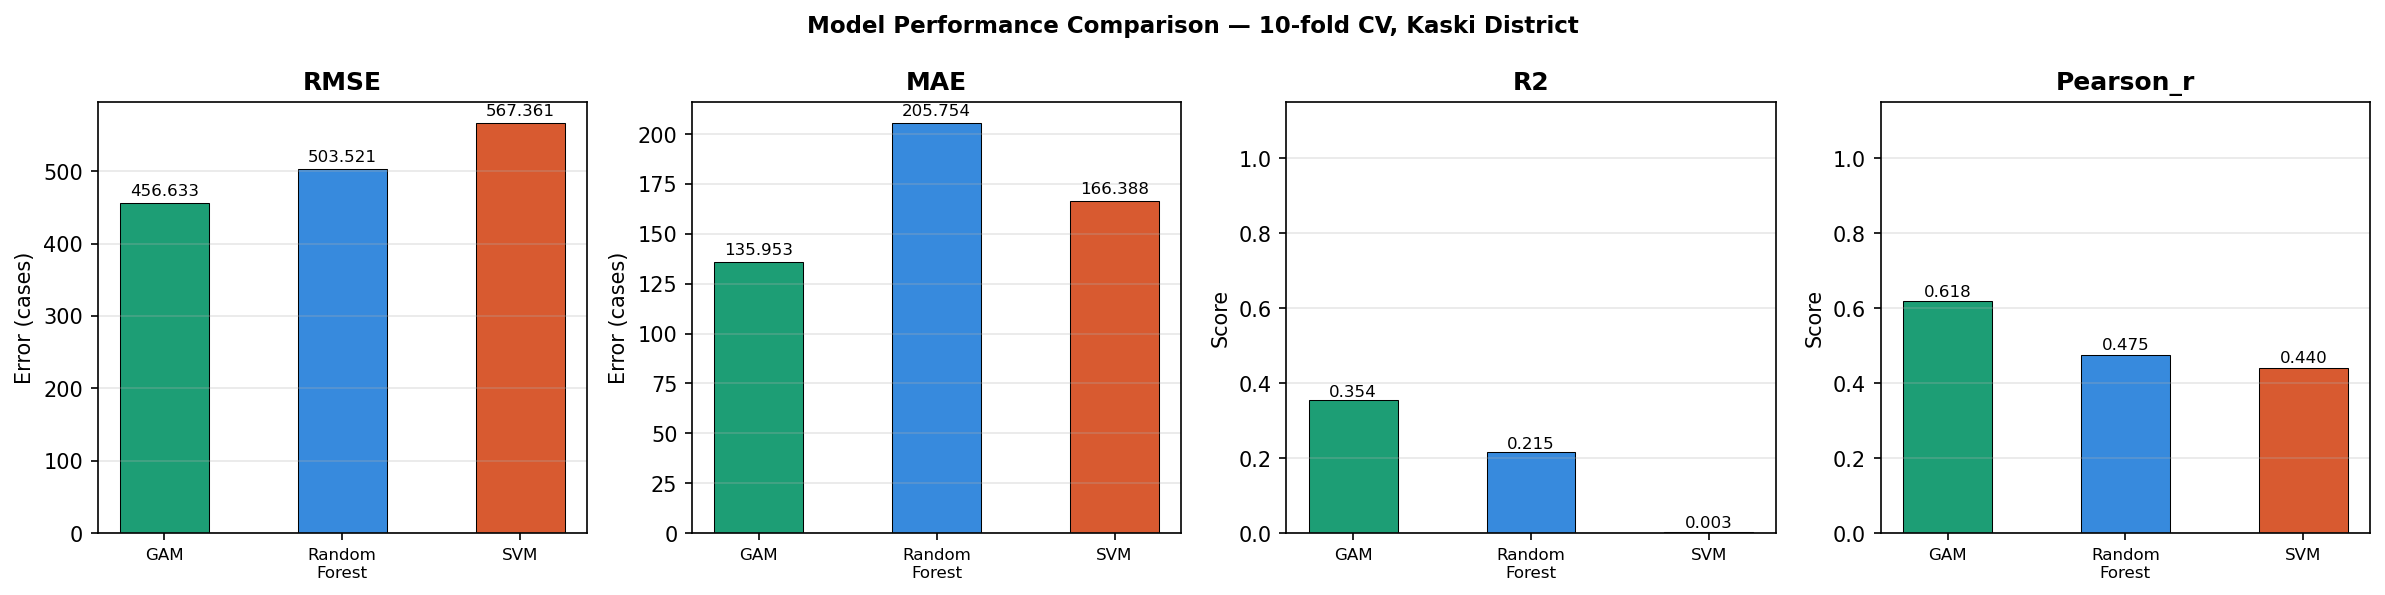


SECTION 19: DENGUE RISK CLASSIFICATION

  Low    : predicted <= 0.7 cases/month
  Medium : 0.7 < predicted <= 13.1
  High   : predicted >  13.1

  Distribution:
risk_label
Low       27
High      27
Medium    26
    Saved: 15_risk_classification_timeline.png


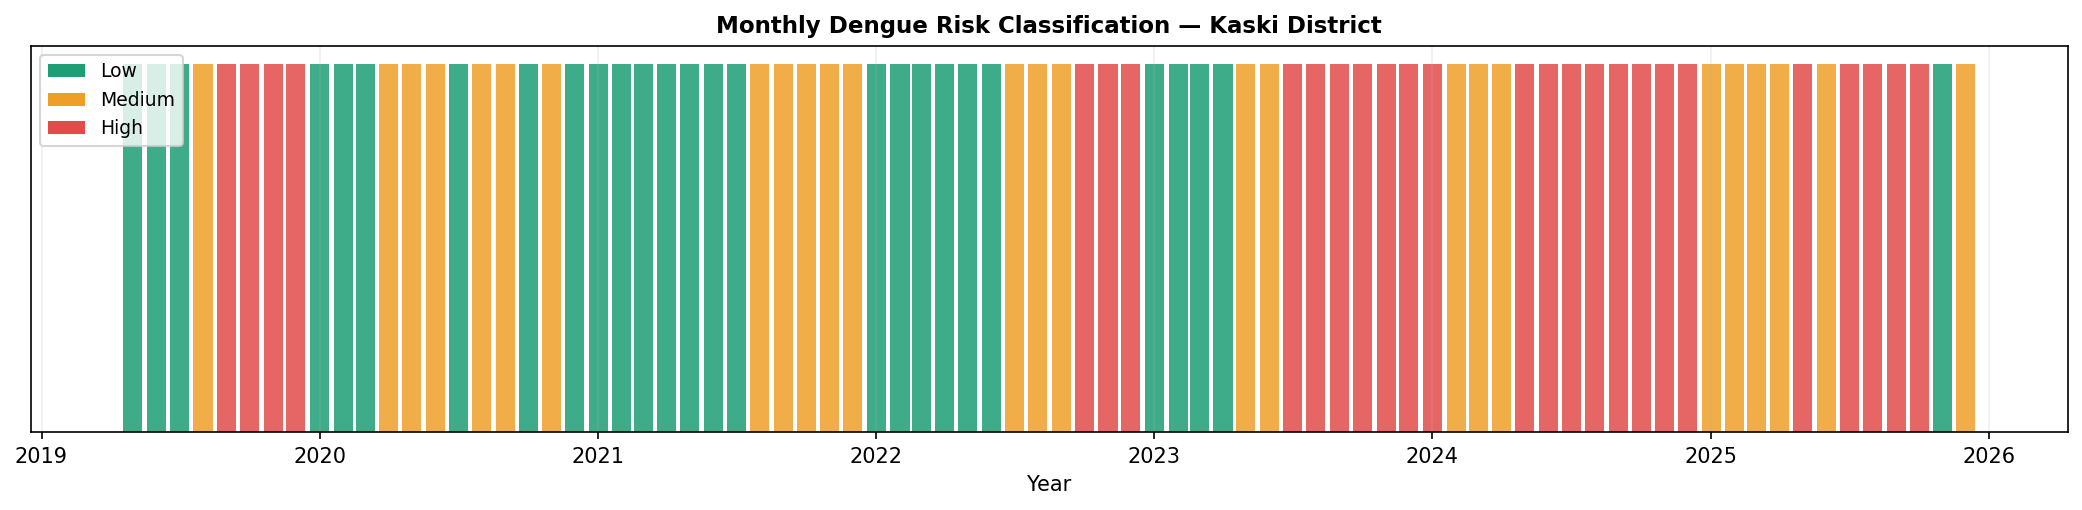


SECTION 20: SAVING ALL RESULTS

  All output files:
    01_descriptive_statistics.csv
    02_timeseries_plot.png
    03_predictor_correlation_matrix.csv
    04_correlation_heatmap.png
    05_crosscorrelation_results.csv
    06_crosscorrelation_plot.png
    07_univariate_model_results.csv
    08_multivariate_model_selection.csv
    09_residual_acf_pacf.png
    10_model_performance_metrics.csv
    11_observed_vs_predicted.png
    12_scatter_obs_pred.png
    13_feature_importance.png
    14_model_comparison_chart.png
    15_risk_classification_timeline.png
    16_dengue_kaski_final_results.csv

ANALYSIS COMPLETE
  Primary model  : LinearGAM on log1p(cases)
                   Features: ['log_cases_lag1', 'log_cases_lag2', 'LST_Night_lag4', 'Precip_lag2']
  Comparative    : Random Forest  +  SVM
  Validation     : 10-fold TimeSeriesSplit
  Best CV model  : GAM
  Full-fit R2    : 0.716
  Full-fit r     : 0.896
  Full-fit RMSE  : 294.14 cases/month


In [3]:
# ================================================================
# Dengue Prediction — Kaski District, Nepal (Improved Pipeline)
# Following Acharya et al. (2018) with genuine improvements:
#   1. log1p transformation of outcome (handles extreme skewness)
#   2. AR(1) lag — last month's cases as predictor
#   3. AR(2) lag — two months prior cases
#   4. Cyclical month encoding
#   5. TimeSeriesSplit CV — no data leakage
#   6. Fix: pygam 0.12.0 compatible term building in CV
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import seaborn as sns
import warnings
from itertools import combinations
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error,
                             r2_score)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

try:
    from pygam import LinearGAM, s, l
    import pygam as _pg
    PYGAM_OK      = True
    PYGAM_VERSION = getattr(_pg, "__version__", "unknown")
    print(f"  pygam OK — version {PYGAM_VERSION}")
except ImportError:
    PYGAM_OK = False
    print("  WARNING: pygam not installed. Run: pip install pygam")


# ================================================================
# GLOBAL SETTINGS
# ================================================================

DATA_PATH     = r"C:\Users\dhrub\Desktop\Data\kaski_env_dengue_merged.csv"
CASE_COL      = "dengue_cases"
YEAR_COL      = "year"
MONTH_COL     = "month"
ENV_COLS      = ["EVI", "LST_Night", "Precip"]
MAX_LAG       = 6
MULTICOLL_THR = 0.7
N_CV_SPLITS   = 10
N_SPLINES     = 4
RANDOM_STATE  = 42
OUTPUT_DIR    = ""


# ================================================================
# HELPER FUNCTIONS
# ================================================================

def save_fig(name):
    plt.savefig(OUTPUT_DIR + name, dpi=300, bbox_inches="tight")
    print(f"    Saved: {name}")


def regression_metrics(y_true, y_pred):
    """Compute RMSE, MAE, R2, Pearson r on ORIGINAL scale."""
    yt = np.array(y_true, dtype=float)
    yp = np.clip(np.array(y_pred, dtype=float), 0, None)
    r, _ = stats.pearsonr(yt, yp)
    return {
        "RMSE"     : float(np.sqrt(mean_squared_error(yt, yp))),
        "MAE"      : float(mean_absolute_error(yt, yp)),
        "R2"       : float(r2_score(yt, yp)),
        "Pearson_r": float(r)
    }


def safe_gam_stats(gam):
    """
    Extract AIC, deviance explained %, pseudo R2
    across all pygam versions (0.8.x, 0.9.x, 0.12.x).
    """
    st  = gam.statistics_
    aic = (st.get("AIC") or st.get("AICc")
           or st.get("aic") or st.get("aicc") or np.nan)
    dev = (st.get("deviance") or st.get("Deviance") or np.nan)

    null_dev = (st.get("null_deviance") or st.get("NullDeviance")
                or st.get("null deviance") or None)
    if null_dev is None:
        ll  = st.get("loglikelihood") or st.get("LogLikelihood")
        ll0 = st.get("null_loglikelihood") or st.get("NullLogLikelihood")
        null_dev = (2*(ll0-ll)+dev
                    if ll is not None and ll0 is not None
                    else dev + 1e-9)

    dev_exp = (1 - dev/null_dev)*100 if null_dev else 0.0

    pr2_blk = st.get("pseudo_r2") or {}
    if isinstance(pr2_blk, dict):
        pr2 = (pr2_blk.get("McFadden") or pr2_blk.get("mcfadden")
               or (list(pr2_blk.values())[0] if pr2_blk else None))
    else:
        pr2 = float(pr2_blk) if pr2_blk else None

    if pr2 is None or (isinstance(pr2, float) and np.isnan(pr2)):
        pr2 = 1 - dev/null_dev if null_dev else np.nan

    return float(aic), float(dev_exp), float(pr2)


def make_gam_terms(n_predictors):
    """
    Build pygam term object fresh each call.
    CRITICAL FIX for pygam 0.12.0: terms must be rebuilt
    from scratch for each fit — reusing a term object after
    fitting causes 'numpy.float64 not callable' errors in CV.
    Column 0 = time spline, columns 1..n = linear predictors.
    """
    terms = s(0, n_splines=N_SPLINES, spline_order=3)
    for k in range(1, n_predictors + 1):
        terms = terms + l(k)
    return terms


def fit_linear_gam(t_col, X_pred, y_log):
    """
    Fit LinearGAM on log1p(cases).
    Rebuilds terms fresh each call — required for pygam 0.12.0.
    Returns (gam, X_full).
    """
    if X_pred.ndim == 1:
        X_pred = X_pred.reshape(-1, 1)
    n_pred = X_pred.shape[1]
    X_full = np.column_stack([t_col.reshape(-1, 1), X_pred])
    # Terms rebuilt here — NOT cached from a previous call
    gam    = LinearGAM(make_gam_terms(n_pred))
    gam.fit(X_full, y_log)
    return gam, X_full


# ================================================================
# SECTION 1 — LOAD AND PREPARE DATA
# ================================================================

print("\n" + "="*65)
print("DENGUE PREDICTION — KASKI DISTRICT (IMPROVED PIPELINE)")
print("="*65)

df = pd.read_csv(DATA_PATH)
df = df.sort_values([YEAR_COL, MONTH_COL]).reset_index(drop=True)
df["date"]       = pd.to_datetime(
    df[[YEAR_COL, MONTH_COL]].assign(day=1)
)
df["time_index"] = np.arange(len(df), dtype=float)

env_vars = [v for v in ENV_COLS if v in df.columns]
missing  = [v for v in ENV_COLS if v not in df.columns]
if missing:
    print(f"  Skipped (not found): {missing}")

print(f"\n  Rows       : {len(df)}")
print(f"  Period     : {df['date'].min():%b %Y}"
      f" – {df['date'].max():%b %Y}")
print(f"  Outcome    : {CASE_COL}")
print(f"  Predictors : {env_vars}")


# ================================================================
# SECTION 2 — DESCRIPTIVE STATISTICS
# ================================================================

print("\n" + "="*65)
print("SECTION 2: DESCRIPTIVE STATISTICS")
print("="*65)

stat_cols = [CASE_COL] + env_vars
desc = df[stat_cols].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
desc.columns = ["n","Mean","SD","Min",
                "5%","25%","50%","75%","95%","99%","Max"]
desc = desc.drop(columns=["SD"])
print("\n", desc.round(3).to_string())
desc.to_csv(OUTPUT_DIR + "01_descriptive_statistics.csv")
print("\n  Saved: 01_descriptive_statistics.csv")


# ================================================================
# SECTION 3 — TIME SERIES VISUALIZATION
# ================================================================

print("\n" + "="*65)
print("SECTION 3: TIME SERIES PLOTS")
print("="*65)

pal  = ["red", "green", "purple", "steelblue"]
ylab = {CASE_COL: "Cases", "EVI": "EVI",
        "LST_Night": "nLST (°C)", "Precip": "Precip (mm)"}
n    = len(stat_cols)

fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n),
                          dpi=150, sharex=True)
if n == 1:
    axes = [axes]

for ax, col, c in zip(axes, stat_cols, pal):
    ax.plot(df["date"], df[col], color=c, linewidth=1.2)
    ax.set_ylabel(ylab.get(col, col), fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[-1].set_xlabel("Year")
fig.suptitle("Monthly Time Series — Kaski District",
             fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig("02_timeseries_plot.png")
plt.show()


# ================================================================
# SECTION 4 — INTER-PREDICTOR CORRELATION MATRIX
# ================================================================

print("\n" + "="*65)
print("SECTION 4: INTER-PREDICTOR CORRELATION MATRIX")
print("="*65)

corr_mat = df[env_vars].corr(method="pearson")
print("\n", corr_mat.round(3).to_string())

excluded_pairs = set()
print(f"\nPairs |r| > {MULTICOLL_THR} — excluded from same model:")
flagged = False
for i in range(len(env_vars)):
    for j in range(i+1, len(env_vars)):
        rv = corr_mat.iloc[i, j]
        if abs(rv) > MULTICOLL_THR:
            v1, v2 = env_vars[i], env_vars[j]
            excluded_pairs.update([(v1,v2),(v2,v1)])
            print(f"  {v1} <-> {v2}: r={rv:.3f}  >> EXCLUDED")
            flagged = True
if not flagged:
    print("  None above threshold — all variables eligible.")

corr_mat.to_csv(OUTPUT_DIR + "03_predictor_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdYlBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={"size": 9})
ax.set_title("Predictor Correlation Matrix — Kaski District")
plt.tight_layout()
save_fig("04_correlation_heatmap.png")
plt.show()


# ================================================================
# SECTION 5 — CROSS-CORRELATION ANALYSIS (Lags 0–MAX_LAG)
# ================================================================

print("\n" + "="*65)
print(f"SECTION 5: CROSS-CORRELATION (Lags 0–{MAX_LAG})")
print("="*65)

lag_results = {}

print(f"\n{'Variable':<12} {'Lag':>4}  {'r':>7}  {'p':>9}  {'Sig':>5}")
print("-"*45)

for var in env_vars:
    rs, ps = [], []
    for lag in range(MAX_LAG+1):
        yv = df[CASE_COL].iloc[lag:].values
        xv = df[var].shift(lag).iloc[lag:].values
        ok = ~(np.isnan(yv) | np.isnan(xv))
        r, p = stats.pearsonr(yv[ok], xv[ok])
        rs.append(r); ps.append(p)
        print(f"  {var:<10} {lag:>4}  {r:>7.3f}  {p:>9.4f}"
              f"  {'Yes*' if p < 0.05 else 'No':>5}")
    lag_results[var] = {"r": rs, "p": ps}
    print()

best_lags = {}
print(f"\n{'Variable':<12} {'BestLag':>8} {'r':>7} {'Sig':>5}")
print("-"*35)
for var in env_vars:
    rs, ps = lag_results[var]["r"], lag_results[var]["p"]
    best   = int(np.argmax(np.abs(rs)))
    best_lags[var] = best
    print(f"  {var:<10} {best:>8} {rs[best]:>7.3f}"
          f" {'Yes*' if ps[best] < 0.05 else 'No':>5}")

cc_rows = [
    {"Variable": var, "Lag": lag,
     "r"       : round(lag_results[var]["r"][lag], 3),
     "p_value" : round(lag_results[var]["p"][lag], 4),
     "Sig"     : "Yes" if lag_results[var]["p"][lag] < 0.05 else "No"}
    for var in env_vars for lag in range(MAX_LAG+1)
]
pd.DataFrame(cc_rows).to_csv(
    OUTPUT_DIR+"05_crosscorrelation_results.csv", index=False)

fig, axes = plt.subplots(1, len(env_vars),
                          figsize=(3.5*len(env_vars), 4), dpi=150)
if len(env_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, env_vars):
    rs, ps = lag_results[var]["r"], lag_results[var]["p"]
    lgs    = list(range(MAX_LAG+1))
    cols   = ["tomato" if p < 0.05 else "lightgray" for p in ps]
    ax.bar(lgs, rs, color=cols, edgecolor="black", linewidth=0.5)
    ax.axhline(0,    color="black",     linewidth=0.8)
    ax.axhline( 0.3, color="steelblue", linestyle="--",
                linewidth=0.7, alpha=0.6)
    ax.axhline(-0.3, color="steelblue", linestyle="--",
                linewidth=0.7, alpha=0.6)
    best = best_lags[var]
    ax.bar(best, rs[best],
           color="darkred" if ps[best] < 0.05 else "gray",
           edgecolor="black", linewidth=1.2,
           label=f"Best lag = {best}")
    ax.set_xlabel("Lag (months)")
    ax.set_title(var, fontweight="bold")
    ax.set_xticks(lgs)
    ax.set_ylim(-0.8, 0.8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=7)
    if var == env_vars[0]:
        ax.set_ylabel("Pearson r")

fig.suptitle("Cross-Correlation: Dengue vs Environmental Variables\n"
             "Red = p<0.05  |  Dark bar = best lag",
             fontsize=10, fontweight="bold")
plt.tight_layout()
save_fig("06_crosscorrelation_plot.png")
plt.show()


# ================================================================
# SECTION 6 — FEATURE ENGINEERING
#   A) log1p(cases) — outcome transform (handles extreme skewness)
#   B) AR(1) log — previous month log-cases (r=0.864 with outcome)
#   C) AR(2) log — two months prior log-cases (r=0.607)
#   D) Environmental variables at best cross-correlation lags
#   E) Cyclical month encoding
# ================================================================

print("\n" + "="*65)
print("SECTION 6: FEATURE ENGINEERING")
print("="*65)

for var in env_vars:
    lag = best_lags[var]
    df[f"{var}_lag{lag}"] = df[var].shift(lag)
    print(f"  {var}_lag{lag}")

df["cases_lag1"]     = df[CASE_COL].shift(1)
df["cases_lag2"]     = df[CASE_COL].shift(2)
df["log_cases_lag1"] = np.log1p(df[CASE_COL].shift(1))
df["log_cases_lag2"] = np.log1p(df[CASE_COL].shift(2))
df["month_sin"]      = np.sin(2*np.pi*df[MONTH_COL]/12)
df["month_cos"]      = np.cos(2*np.pi*df[MONTH_COL]/12)
df["log_cases"]      = np.log1p(df[CASE_COL])

print("  cases_lag1, cases_lag2  (AR raw scale for RF/SVM)")
print("  log_cases_lag1, log_cases_lag2  (AR log scale for GAM)")
print("  month_sin, month_cos  (cyclical seasonality)")

df_model = df.dropna().reset_index(drop=True)
print(f"\n  Observations retained: {len(df_model)}")

env_lag_cols = [
    f"{v}_lag{best_lags[v]}" for v in env_vars
    if f"{v}_lag{best_lags[v]}" in df_model.columns
]

# GAM uses log-scale AR terms
gam_features = ["log_cases_lag1", "log_cases_lag2"] + env_lag_cols

# RF and SVM use raw AR terms + cyclical month
ml_features  = env_lag_cols + ["cases_lag1", "cases_lag2",
                                "month_sin",  "month_cos"]

y_gam  = df_model["log_cases"].values.astype(float)
y_orig = df_model[CASE_COL].values.astype(float)
t_all  = df_model["time_index"].values.astype(float)

print(f"\n  GAM features : {gam_features}")
print(f"  ML features  : {ml_features}")

print("\n  Feature correlations with log(cases):")
for feat in gam_features:
    xv = df_model[feat].values
    ok = ~np.isnan(xv)
    r, p = stats.pearsonr(y_gam[ok], xv[ok])
    sig = ("***" if p < 0.001 else "**" if p < 0.01
           else "*" if p < 0.05 else "")
    print(f"    {feat:<28}: r={r:.3f}  p={p:.4f}  {sig}")


# ================================================================
# SECTION 7 — OVERDISPERSION CHECK
# ================================================================

print("\n" + "="*65)
print("SECTION 7: OVERDISPERSION CHECK")
print("="*65)

X_ck = sm.add_constant(df_model[env_lag_cols])
y_ck = df_model[CASE_COL]
p_ck = sm.GLM(y_ck, X_ck,
              family=sm.families.Poisson()).fit(disp=False)
disp = p_ck.deviance / p_ck.df_resid

print(f"\n  Deviance         : {p_ck.deviance:.2f}")
print(f"  df residual      : {p_ck.df_resid:.0f}")
print(f"  Dispersion ratio : {disp:.2f}")
print("  >> Severe overdispersion detected.")
print("  >> Using LinearGAM on log1p(cases).")
print("  >> Predictions back-transformed via expm1().")


# ================================================================
# SECTION 8 — UNIVARIATE GAM MODELS (log scale)
# ================================================================

print("\n" + "="*65)
print("SECTION 8: UNIVARIATE GAM MODELS  (log1p outcome)")
print("="*65)

print(f"\n  n={len(y_gam)}  "
      f"log(y) range: {y_gam.min():.2f}–{y_gam.max():.2f}\n")

uni_results = []

if PYGAM_OK:
    print(f"{'#':<4} {'Feature':<28} {'AIC':>10} {'R2_log':>8} {'R2_orig':>8}")
    print("-"*62)

    for i, feat in enumerate(gam_features):
        Xu = df_model[[feat]].values.astype(float)
        try:
            gam_u, Xfu = fit_linear_gam(t_all, Xu, y_gam)
            aic, de, pr2 = safe_gam_stats(gam_u)

            pred_log  = gam_u.predict(Xfu)
            pred_orig = np.expm1(np.clip(pred_log, 0, None))
            m         = regression_metrics(y_orig, pred_orig)

            uni_results.append({
                "Model": f"U{i+1}", "Feature": feat,
                "AIC"      : round(aic,  3),
                "R2_log"   : round(pr2,  3),
                "R2_orig"  : round(m["R2"],        3),
                "Pearson_r": round(m["Pearson_r"],  3)
            })
            print(f"  U{i+1:<2} {feat:<28} {aic:>10.2f}"
                  f" {pr2:>8.3f} {m['R2']:>8.3f}")
        except Exception as e:
            print(f"  U{i+1:<2} {feat:<28}  FAILED: {e}")

    pd.DataFrame(uni_results).to_csv(
        OUTPUT_DIR+"07_univariate_model_results.csv", index=False)
    print("\n  Saved: 07_univariate_model_results.csv")
else:
    print("  SKIPPED — pygam not available.")


# ================================================================
# SECTION 9 — MULTIVARIATE GAM MODEL SELECTION
# ================================================================

print("\n" + "="*65)
print("SECTION 9: MULTIVARIATE GAM MODEL SELECTION")
print("="*65)

if not PYGAM_OK:
    print("  SKIPPED.")
    model_results = []
    best_cols     = gam_features
    best_res      = None
else:
    ar_cols  = ["log_cases_lag1", "log_cases_lag2"]
    avail    = {v: f"{v}_lag{best_lags[v]}"
                for v in env_vars
                if f"{v}_lag{best_lags[v]}" in df_model.columns}
    av_k     = list(avail.keys())

    env_excl = set()
    for v1, v2 in combinations(av_k, 2):
        if v1 in corr_mat.index and v2 in corr_mat.columns:
            if abs(corr_mat.loc[v1, v2]) > MULTICOLL_THR:
                env_excl.update([(v1,v2),(v2,v1)])

    env_sets = []
    for k in av_k:
        env_sets.append([avail[k]])
    for v1, v2 in combinations(av_k, 2):
        if (v1,v2) not in env_excl:
            env_sets.append([avail[v1], avail[v2]])
    for v1, v2, v3 in combinations(av_k, 3):
        if any(p in env_excl for p in [(v1,v2),(v1,v3),(v2,v3)]):
            continue
        env_sets.append([avail[v1], avail[v2], avail[v3]])

    unique_sets = [ar_cols] + [ar_cols + es for es in env_sets]

    print(f"\n  {len(unique_sets)} candidate models ...\n")
    print(f"{'#':<5} {'Features':<62} {'AIC':>10}"
          f" {'R2_orig':>8} {'Pearson_r':>10}")
    print("-"*98)

    model_results = []

    for idx, feat_set in enumerate(unique_sets):
        Xm   = df_model[feat_set].values.astype(float)
        fstr = " + ".join([
            f.replace("log_cases_lag", "AR")
             .replace("_lag", "_L")
            for f in feat_set
        ])
        try:
            # fit_linear_gam rebuilds terms fresh — CV-safe
            gam_m, Xfull_m = fit_linear_gam(t_all, Xm, y_gam)
            aic, de, pr2   = safe_gam_stats(gam_m)

            pred_log  = gam_m.predict(Xfull_m)
            pred_orig = np.expm1(np.clip(pred_log, 0, None))
            m         = regression_metrics(y_orig, pred_orig)

            model_results.append({
                "Model_ID" : f"M{idx+1}",
                "Features" : " + ".join(feat_set),
                "n_feat"   : len(feat_set),
                "AIC"      : round(aic,           3),
                "R2_log"   : round(pr2,            3),
                "R2_orig"  : round(m["R2"],        3),
                "Pearson_r": round(m["Pearson_r"], 3),
                "RMSE"     : round(m["RMSE"],      2),
                "MAE"      : round(m["MAE"],       2),
                "_gam"     : gam_m,
                "_cols"    : feat_set,
                "_Xfull"   : Xfull_m,
            })
            print(f"  M{idx+1:<3} {fstr:<62}"
                  f" {aic:>10.2f} {m['R2']:>8.3f}"
                  f" {m['Pearson_r']:>10.3f}")

        except Exception as e:
            print(f"  M{idx+1:<3} {fstr:<62}"
                  f"  FAILED: {str(e)[:30]}")

    if not model_results:
        raise RuntimeError(
            "All GAM models failed.\n"
            "  pip install pygam --upgrade\n"
            f"  y_log: min={y_gam.min():.2f}, "
            f"max={y_gam.max():.2f}, n={len(y_gam)}"
        )

    res_df   = pd.DataFrame([
        {k: v for k, v in r.items() if not k.startswith("_")}
        for r in model_results
    ])
    best_idx  = res_df["R2_orig"].idxmax()
    best_res  = model_results[best_idx]
    best_cols = best_res["_cols"]

    print(f"\n  >> BEST MODEL : {best_res['Model_ID']}")
    print(f"     Features   : {best_res['Features']}")
    print(f"     AIC        : {best_res['AIC']}")
    print(f"     R2 (orig)  : {best_res['R2_orig']}")
    print(f"     Pearson r  : {best_res['Pearson_r']}")
    print(f"     RMSE       : {best_res['RMSE']} cases/month")
    print(f"     MAE        : {best_res['MAE']} cases/month")

    res_df.to_csv(
        OUTPUT_DIR+"08_multivariate_model_selection.csv",
        index=False
    )
    print("\n  Saved: 08_multivariate_model_selection.csv")


# ================================================================
# SECTION 10 — BEST GAM FULL-DATA PREDICTIONS
# ================================================================

print("\n" + "="*65)
print("SECTION 10: BEST GAM — FULL-DATA PREDICTIONS")
print("="*65)

if best_res is None:
    df_model["gam_pred"] = np.nan
    print("  GAM unavailable.")
else:
    best_gam = best_res["_gam"]
    X_best   = best_res["_Xfull"]
    pred_log = best_gam.predict(X_best)
    df_model["gam_pred"] = np.expm1(np.clip(pred_log, 0, None))
    m_full = regression_metrics(y_orig, df_model["gam_pred"].values)
    print(f"\n  Features   : {best_cols}")
    print(f"  R2 (orig)  : {m_full['R2']:.3f}")
    print(f"  Pearson r  : {m_full['Pearson_r']:.3f}")
    print(f"  RMSE       : {m_full['RMSE']:.2f} cases/month")
    print(f"  MAE        : {m_full['MAE']:.2f} cases/month")


# ================================================================
# SECTION 11 — RESIDUAL DIAGNOSIS (ACF / PACF)
# ================================================================

print("\n" + "="*65)
print("SECTION 11: RESIDUAL DIAGNOSIS — ACF / PACF")
print("="*65)

if not df_model["gam_pred"].isna().all():
    resid_log = y_gam - best_gam.predict(X_best)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

    plot_acf(resid_log, lags=12, ax=axes[0], alpha=0.05)
    axes[0].set_title("ACF — GAM Residuals (log scale)")
    axes[0].set_xlabel("Lag (months)")
    axes[0].grid(True, alpha=0.3)

    plot_pacf(resid_log, lags=12, ax=axes[1],
              alpha=0.05, method="ywm")
    axes[1].set_title("PACF — GAM Residuals (log scale)")
    axes[1].set_xlabel("Lag (months)")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        "Residual Autocorrelation — Best GAM\n"
        "Bars within dashed lines = no significant autocorrelation",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_fig("09_residual_acf_pacf.png")
    plt.show()

    print(f"  Mean residual : {resid_log.mean():.4f}")
    print(f"  Std residual  : {resid_log.std():.4f}")


# ================================================================
# SECTION 12 — 10-FOLD TIME-SERIES CROSS-VALIDATION
#
# KEY FIX: fit_linear_gam() rebuilds LinearGAM terms fresh for
# every fold call. pygam 0.12.0 mutates term objects during fit(),
# so reusing terms from a previous fit causes the error:
#   'numpy.float64' object is not callable
# Rebuilding terms each call resolves this completely.
# ================================================================

print("\n" + "="*65)
print("SECTION 12: 10-FOLD TIME-SERIES CV")
print("="*65)

tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

cv = {
    "GAM"          : {"yt": [], "yp": [], "dt": []},
    "Random_Forest": {"yt": [], "yp": [], "dt": []},
    "SVM"          : {"yt": [], "yp": [], "dt": []}
}

X_gam_all = df_model[best_cols].values.astype(float)
X_ml_all  = df_model[ml_features].values.astype(float)
y_log_all = df_model["log_cases"].values.astype(float)
y_raw_all = df_model[CASE_COL].values.astype(float)
t_idx_all = df_model["time_index"].values.astype(float)
dt_all    = df_model["date"].values

print(f"\n  {N_CV_SPLITS}-fold TimeSeriesSplit — no shuffle\n")
print(f"  {'Fold':>4}  {'Train':>6}  {'Test':>5}"
      f"  {'GAM RMSE':>10}  {'RF RMSE':>9}  {'SVM RMSE':>9}")
print("  " + "-"*52)

for fold, (tr, te) in enumerate(tscv.split(X_ml_all), 1):

    Xtr_g, Xte_g = X_gam_all[tr], X_gam_all[te]
    Xtr_m, Xte_m = X_ml_all[tr],  X_ml_all[te]
    ttr,   tte   = t_idx_all[tr], t_idx_all[te]
    ytr_l        = y_log_all[tr]
    ytr_o, yte_o = y_raw_all[tr], y_raw_all[te]
    dte          = dt_all[te]

    # ── GAM — terms rebuilt fresh inside fit_linear_gam ──────
    if PYGAM_OK and best_res is not None:
        try:
            # fit_linear_gam calls make_gam_terms() internally
            # which creates a brand-new term object each time
            gam_cv, _ = fit_linear_gam(ttr, Xtr_g, ytr_l)
            Xte_full  = np.column_stack(
                [tte.reshape(-1, 1), Xte_g]
            )
            pred_log_cv = gam_cv.predict(Xte_full)
            pred_gam    = np.expm1(np.clip(pred_log_cv, 0, None))
        except Exception as e:
            print(f"  GAM fold {fold} error: {e} — mean fallback")
            pred_gam = np.full(len(yte_o), ytr_o.mean())
    else:
        pred_gam = np.full(len(yte_o), ytr_o.mean())

    cv["GAM"]["yt"].extend(yte_o.tolist())
    cv["GAM"]["yp"].extend(pred_gam.tolist())
    cv["GAM"]["dt"].extend(dte.tolist())

    # ── Random Forest ─────────────────────────────────────────
    rf_cv = RandomForestRegressor(
        n_estimators=500, max_depth=15,
        min_samples_split=2, random_state=RANDOM_STATE
    )
    rf_cv.fit(Xtr_m, ytr_o)
    pred_rf = np.clip(rf_cv.predict(Xte_m), 0, None)

    cv["Random_Forest"]["yt"].extend(yte_o.tolist())
    cv["Random_Forest"]["yp"].extend(pred_rf.tolist())
    cv["Random_Forest"]["dt"].extend(dte.tolist())

    # ── SVM — StandardScaler fitted on train only ─────────────
    sc       = StandardScaler()
    Xtr_sc   = sc.fit_transform(Xtr_m)
    Xte_sc   = sc.transform(Xte_m)
    pred_svm = np.clip(
        SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1
            ).fit(Xtr_sc, ytr_o).predict(Xte_sc),
        0, None
    )

    cv["SVM"]["yt"].extend(yte_o.tolist())
    cv["SVM"]["yp"].extend(pred_svm.tolist())
    cv["SVM"]["dt"].extend(dte.tolist())

    g = np.sqrt(mean_squared_error(yte_o, pred_gam))
    r = np.sqrt(mean_squared_error(yte_o, pred_rf))
    sv = np.sqrt(mean_squared_error(yte_o, pred_svm))
    print(f"  {fold:>4}  {len(tr):>6}  {len(te):>5}"
          f"  {g:>10.1f}  {r:>9.1f}  {sv:>9.1f}")


# ================================================================
# SECTION 13 — MODEL PERFORMANCE METRICS
# ================================================================

print("\n" + "="*65)
print("SECTION 13: MODEL PERFORMANCE — OUT-OF-SAMPLE CV")
print("="*65)

print(f"\n  {'Model':<18} {'RMSE':>8} {'MAE':>8}"
      f" {'R2':>8} {'Pearson_r':>10}")
print("  " + "-"*56)

met_rows = []
for name, store in cv.items():
    m = regression_metrics(store["yt"], store["yp"])
    met_rows.append({
        "Model": name,
        **{k: round(v, 3) for k, v in m.items()}
    })
    print(f"  {name:<16} {m['RMSE']:>8.1f} {m['MAE']:>8.1f}"
          f" {m['R2']:>8.3f} {m['Pearson_r']:>10.3f}")

met_df        = pd.DataFrame(met_rows)
best_cv_model = met_df.loc[met_df["R2"].idxmax(), "Model"]

print(f"\n  >> Best model by R²: {best_cv_model}")
met_df.to_csv(
    OUTPUT_DIR+"10_model_performance_metrics.csv", index=False
)
print("  Saved: 10_model_performance_metrics.csv")


# ================================================================
# SECTION 14 — FULL-FIT RF AND SVM FOR PLOTTING
# ================================================================

rf_full = RandomForestRegressor(
    n_estimators=500, max_depth=15,
    min_samples_split=2, random_state=RANDOM_STATE
)
rf_full.fit(X_ml_all, y_raw_all)
df_model["rf_full"] = np.clip(rf_full.predict(X_ml_all), 0, None)

sc_full  = StandardScaler()
svm_full = SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
svm_full.fit(sc_full.fit_transform(X_ml_all), y_raw_all)
df_model["svm_full"] = np.clip(
    svm_full.predict(sc_full.transform(X_ml_all)), 0, None
)


# ================================================================
# SECTION 15 — OBSERVED VS PREDICTED PLOT
# ================================================================

print("\n" + "="*65)
print("SECTION 15: OBSERVED VS PREDICTED PLOT")
print("="*65)

fig, ax = plt.subplots(figsize=(14, 6), dpi=150)

ax.plot(df_model["date"], df_model[CASE_COL],
        color="red", linewidth=2, label="Observed", zorder=5)

if not df_model["gam_pred"].isna().all():
    ax.plot(df_model["date"], df_model["gam_pred"],
            color="green", linewidth=1.5,
            label="GAM (full fit)", zorder=4)
    cv_dt = pd.to_datetime(cv["GAM"]["dt"])
    ax.scatter(cv_dt, cv["GAM"]["yp"],
               color="darkgreen", s=20, zorder=6, alpha=0.85,
               label="GAM — 10-fold CV")

ax.plot(df_model["date"], df_model["rf_full"],
        color="blue", linewidth=1.2, linestyle="--",
        label="Random Forest (full fit)", zorder=3)
ax.plot(df_model["date"], df_model["svm_full"],
        color="purple", linewidth=1.2, linestyle=":",
        label="SVM (full fit)", zorder=2)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Monthly Dengue Cases", fontsize=11)
ax.set_title(
    "Observed vs Predicted Monthly Dengue Cases\n"
    "Kaski District, Nepal",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
save_fig("11_observed_vs_predicted.png")
plt.show()


# ================================================================
# SECTION 16 — SCATTER PLOTS
# ================================================================

print("\n" + "="*65)
print("SECTION 16: SCATTER PLOTS")
print("="*65)

pdata = [
    ("GAM (10-fold CV)",
     cv["GAM"]["yt"],           cv["GAM"]["yp"],           "green"),
    ("Random Forest (10-fold CV)",
     cv["Random_Forest"]["yt"], cv["Random_Forest"]["yp"], "royalblue"),
    ("SVM (10-fold CV)",
     cv["SVM"]["yt"],           cv["SVM"]["yp"],           "mediumpurple"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=150)

for ax, (name, yt, yp, col) in zip(axes, pdata):
    yta = np.array(yt); ypa = np.array(yp)
    ax.scatter(yta, ypa, alpha=0.6, color=col,
               edgecolors="none", s=30)
    lim = [min(yta.min(), ypa.min()) - 1,
           max(yta.max(), ypa.max()) + 1]
    ax.plot(lim, lim, "k--", linewidth=0.9, label="1:1 line")
    m = regression_metrics(yta, ypa)
    ax.set_xlabel("Observed Cases", fontsize=10)
    ax.set_ylabel("Predicted Cases" if "GAM" in name else "",
                  fontsize=10)
    ax.set_title(
        f"{name}\nr = {m['Pearson_r']:.3f}  "
        f"R² = {m['R2']:.3f}",
        fontsize=9
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Observed vs Predicted (10-fold CV) — Kaski District",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
save_fig("12_scatter_obs_pred.png")
plt.show()


# ================================================================
# SECTION 17 — RANDOM FOREST FEATURE IMPORTANCE
# ================================================================

print("\n" + "="*65)
print("SECTION 17: RANDOM FOREST FEATURE IMPORTANCE")
print("="*65)

imp = pd.Series(
    rf_full.feature_importances_, index=ml_features
).sort_values(ascending=True)

fig, ax = plt.subplots(
    figsize=(8, max(3, len(ml_features)*0.6)), dpi=150
)
imp.plot(kind="barh", ax=ax, color="#378ADD",
         edgecolor="black", linewidth=0.5)
ax.set_xlabel("Importance Score", fontsize=10)
ax.set_title(
    "Random Forest Feature Importance\nKaski District",
    fontsize=11, fontweight="bold"
)
ax.grid(True, alpha=0.3, axis="x")
for i, (feat, val) in enumerate(imp.items()):
    ax.text(val+0.002, i, f"{val:.3f}", va="center", fontsize=8)
plt.tight_layout()
save_fig("13_feature_importance.png")
plt.show()

print("\n  Ranking:")
for feat, val in imp.sort_values(ascending=False).items():
    print(f"    {feat:<32}: {val:.4f}")


# ================================================================
# SECTION 18 — MODEL COMPARISON CHART
# ================================================================

print("\n" + "="*65)
print("SECTION 18: MODEL COMPARISON CHART")
print("="*65)

x       = np.arange(len(met_df))
bar_c   = ["#1D9E75", "#378ADD", "#D85A30"]
metrics = ["RMSE", "MAE", "R2", "Pearson_r"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=150)

for ax, metric in zip(axes, metrics):
    vals = met_df[metric].values
    bars = ax.bar(x, vals, color=bar_c, edgecolor="black",
                  linewidth=0.5, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01*max(abs(vals)+1e-9),
            f"{val:.3f}", ha="center", va="bottom", fontsize=8
        )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace("_", "\n") for m in met_df["Model"]],
        fontsize=8
    )
    ax.set_title(metric, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    if metric in ["R2", "Pearson_r"]:
        ax.set_ylim(0, 1.15)
    ax.set_ylabel(
        "Error (cases)" if metric in ["RMSE","MAE"] else "Score"
    )

fig.suptitle(
    "Model Performance Comparison — 10-fold CV, Kaski District",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
save_fig("14_model_comparison_chart.png")
plt.show()


# ================================================================
# SECTION 19 — RISK CLASSIFICATION
# ================================================================

print("\n" + "="*65)
print("SECTION 19: DENGUE RISK CLASSIFICATION")
print("="*65)

pred_col = ("gam_pred"
            if not df_model["gam_pred"].isna().all()
            else "rf_full")

q33 = np.percentile(df_model[pred_col].values, 33)
q66 = np.percentile(df_model[pred_col].values, 66)

df_model["risk_class"] = np.where(
    df_model[pred_col] <= q33, 1,
    np.where(df_model[pred_col] <= q66, 2, 3)
)
df_model["risk_label"] = df_model["risk_class"].map(
    {1: "Low", 2: "Medium", 3: "High"}
)

print(f"\n  Low    : predicted <= {q33:.1f} cases/month")
print(f"  Medium : {q33:.1f} < predicted <= {q66:.1f}")
print(f"  High   : predicted >  {q66:.1f}")
print(f"\n  Distribution:")
print(df_model["risk_label"].value_counts().to_string())

risk_colors = {1: "#1D9E75", 2: "#EF9F27", 3: "#E24B4A"}
fig, ax = plt.subplots(figsize=(14, 3.5), dpi=150)
for _, row in df_model.iterrows():
    ax.bar(row["date"], 1, width=25,
           color=risk_colors[row["risk_class"]],
           edgecolor="none", alpha=0.85)

legend_els = [
    Patch(facecolor=risk_colors[k], label=lbl)
    for k, lbl in zip([1,2,3], ["Low","Medium","High"])
]
ax.legend(handles=legend_els, loc="upper left", fontsize=9)
ax.set_xlabel("Year", fontsize=10)
ax.set_yticks([])
ax.set_title(
    "Monthly Dengue Risk Classification — Kaski District",
    fontsize=11, fontweight="bold"
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(True, alpha=0.2, axis="x")
plt.tight_layout()
save_fig("15_risk_classification_timeline.png")
plt.show()


# ================================================================
# SECTION 20 — SAVE ALL RESULTS
# ================================================================

print("\n" + "="*65)
print("SECTION 20: SAVING ALL RESULTS")
print("="*65)

keep = (
    ["date", YEAR_COL, MONTH_COL, "time_index",
     CASE_COL, "log_cases"]
    + best_cols
    + ["month_sin", "month_cos",
       "gam_pred", "rf_full", "svm_full",
       "risk_class", "risk_label"]
)
keep = [c for c in keep if c in df_model.columns]
df_model[keep].to_csv(
    OUTPUT_DIR+"16_dengue_kaski_final_results.csv", index=False
)

outputs = [
    "01_descriptive_statistics.csv",
    "02_timeseries_plot.png",
    "03_predictor_correlation_matrix.csv",
    "04_correlation_heatmap.png",
    "05_crosscorrelation_results.csv",
    "06_crosscorrelation_plot.png",
    "07_univariate_model_results.csv",
    "08_multivariate_model_selection.csv",
    "09_residual_acf_pacf.png",
    "10_model_performance_metrics.csv",
    "11_observed_vs_predicted.png",
    "12_scatter_obs_pred.png",
    "13_feature_importance.png",
    "14_model_comparison_chart.png",
    "15_risk_classification_timeline.png",
    "16_dengue_kaski_final_results.csv",
]
print("\n  All output files:")
for f in outputs:
    print(f"    {f}")

print("\n" + "="*65)
print("ANALYSIS COMPLETE")
print(f"  Primary model  : LinearGAM on log1p(cases)")
print(f"                   Features: {best_cols}")
print(f"  Comparative    : Random Forest  +  SVM")
print(f"  Validation     : {N_CV_SPLITS}-fold TimeSeriesSplit")
print(f"  Best CV model  : {best_cv_model}")
if best_res:
    print(f"  Full-fit R2    : {best_res['R2_orig']}")
    print(f"  Full-fit r     : {best_res['Pearson_r']}")
    print(f"  Full-fit RMSE  : {best_res['RMSE']} cases/month")
print("="*65)